In [ ]:
print('Running imports...')
import os
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"

import wandb
import torch # long
from lightning.pytorch import loggers, seed_everything
import xarray as xr
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import argparse
from collections import OrderedDict

import sys
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')


from ml_module_rain.models.neuralnetworks import get_neural_network, register_shape_hooks
from ml_module_rain.models.individualblocks import *
from ml_module_rain.data.datamodule import MyDataLoader
from ml_module_rain.models.lightning import ExtremeRainPredictor, AttributableTrainer
from ml_module_rain.models.losses import get_loss
from ml_module_rain.models.callbacks import LogF1Validation, get_checkpoint_callback, BestF1Callback
from ml_module_rain.utils.config import load_config
# from ml_module_rain.models.losses import load_config
import matplotlib.pyplot as plt
from pathlib import Path
import torch.nn as nn

Running imports...


In [2]:
import torch.functional as F
def get_act(name: str):
    return {"ReLU": nn.ReLU(inplace=False),
            "LeakyReLU": nn.LeakyReLU(inplace=False),
            "GELU": nn.GELU(),
            }.get(name, nn.ReLU(inplace=False))

def get_norm(use_bn: bool, C: int):
    return nn.BatchNorm2d(C) if use_bn else nn.Identity()

def pad_to_even(x):
    # right/bottom pad to mimic ceil-style downsampling on odd H/W
    ph = x.shape[-2] & 1
    pw = x.shape[-1] & 1
    return F.pad(x, (0, pw, 0, ph)) if (ph or pw) else x
class SingleConv(nn.Module):
    def __init__(self, in_ch, out_ch, act="ReLU", use_bn=True, p_drop=0.0):
        super().__init__()
        self.convolution = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=use_bn is False)
        self.batchnorm= get_norm(use_bn, out_ch)
        self.activation= get_act(act)
        self.dropout= nn.Dropout2d(p_drop) if p_drop > 0 else nn.Identity()
        
    def forward(self, x): 
        out = self.convolution(x)
        out = self.batchnorm(out)
        out = self.activation(out)
        out = self.dropout(out)
        return out
    

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, act="ReLU", use_bn=True, p_drop=0.0):
        super().__init__()
        self.conv1 = SingleConv(in_ch, out_ch, act=act, use_bn=use_bn, p_drop=p_drop)
        self.conv2 = SingleConv(out_ch, out_ch, act=act, use_bn=use_bn, p_drop=p_drop)
    def forward(self, x): 
        out = self.conv1(x)
        out = self.conv2(out)
        return out


class Downsample(nn.Module):
    """
    mode: 'maxpool', 'avgpool', 'strideconv', or None
    kernel_stride: kernel/stride for pool, or stride for strideconv
    conv_kernel: kernel for strideconv (2 mimics your old 2x2; 3 is common)
    ceil: if True, mimic ceil_mode semantics on odd H/W via right/bottom pad
    """
    def __init__(self, C, mode="maxpool", kernel_stride=2, conv_kernel=3, ceil=True, use_bn=True, act="ReLU"):
        super().__init__()
        self.mode = mode
        self.ceil = ceil
        if mode is None:
            self.down = nn.Identity()
        elif mode == "maxpool":
            self.down = nn.MaxPool2d(kernel_stride, kernel_stride, ceil_mode=ceil)
        elif mode == "avgpool":
            self.down = nn.AvgPool2d(kernel_stride, kernel_stride, ceil_mode=ceil)
        elif mode == "strideconv":
            # stride-2 conv as a downsampler; keep norm+act for stability
            self.down = nn.Conv2d(C, C, conv_kernel, stride=2, padding=conv_kernel//2, bias=use_bn is False)
        else:
            raise ValueError(f"{mode} should be one of 'strideconv','maxpool' or 'avgpool'")

    def forward(self, x):
        if self.mode in ("strideconv", None):
            return self.down(x)
        if self.ceil:
            x = pad_to_even(x)
        return self.down(x)


class DownBlock(nn.Module):
    """(Single/Double)Conv → Downsample"""
    def __init__(self, in_ch, out_ch, conv_multiple="double", down_mode="maxpool",
                 act="ReLU", use_bn=True, p_drop=0.0, ceil=True, conv_down_kernel=3):
        super().__init__()
        feat = DoubleConv if conv_multiple == "double" else SingleConv
        self.feat = feat(in_ch, out_ch, act=act, use_bn=use_bn, p_drop=p_drop)
        self.down = Downsample(out_ch, mode=down_mode, conv_kernel=conv_down_kernel,
                               ceil=ceil, use_bn=use_bn, act=act)
    def forward(self, x):
        x = self.feat(x)
        x = self.down(x)
        return x


class ResidualBlock(nn.Module):
    """(Single/Double)Conv + residual"""
    def __init__(self, in_ch, out_ch, conv_multiple="double",
                 act="ReLU", use_bn=True, p_drop=0.0, ceil=True, conv_down_kernel=3):
        super().__init__()
        convfeat = DoubleConv if conv_multiple == "double" else SingleConv
        self.mainconvolution = convfeat(in_ch, out_ch, act=act, use_bn=use_bn, p_drop=p_drop)
        
        proj = nn.Conv2d(in_ch, out_ch, 1, bias=use_bn is False)
        self.projection = nn.Sequential(OrderedDict([('projection_block', proj),('batchnorm',get_norm(use_bn, out_ch))]),)
        self.activation = get_act(act)
        
    def forward(self, x):
        out1 = self.mainconvolution(x)
        out2 = self.projection(x)
        return self.activation(out1+out2)
    
class ResidualDownBlock(nn.Module):
    """(Single/Double)Conv → Downsample"""
    def __init__(self, in_ch, out_ch, conv_multiple="double", down_mode="maxpool",
                 act="ReLU", use_bn=True, p_drop=0.0, ceil=True, conv_down_kernel=3):
        super().__init__()
        self.residual_convolution = ResidualBlock(in_ch, out_ch, conv_multiple=conv_multiple,
                 act=act, use_bn=use_bn, p_drop=p_drop, ceil=ceil, conv_down_kernel=conv_down_kernel)
        self.down = Downsample(out_ch, mode=down_mode, conv_kernel=conv_down_kernel,
                               ceil=ceil, use_bn=use_bn, act=act)
    def forward(self, x):
        out = self.residual_convolution(x)
        out = self.down(out)
        return out


class MLP(nn.Module):
    def __init__(self, 
                 input_neurons, 
                 output_neurons,
                 hidden_layers_neuron_number = [128,512,512,128],
                 dropout = 0,
                 activation_function='ReLU',
                 ):
        super(MLP, self).__init__()
        self.number_layers = len(hidden_layers_neuron_number) + 1
        self.input_neurons = input_neurons
        self.output_neurons = output_neurons
        self.neurons = [input_neurons] + hidden_layers_neuron_number + [output_neurons]
        
        for i in range(1,len(self.neurons)):
            list_modules = [("linearlayer",nn.Linear(self.neurons[i-1], self.neurons[i]))]
            if i < self.number_layers:
                list_modules += [("activation",get_act(activation_function)),
                                 ("dropout", nn.Dropout(p=dropout))]
            layer = nn.Sequential(OrderedDict(list_modules))
            setattr(self, f"fc{i}", layer )

    def forward(self, x):
        for i in range(1, self.number_layers+1):
            x = getattr(self, f"fc{i}" )(x)
        
        return x


In [11]:
X = torch.ones(512,256)
MLP(256,7)(X).shape

torch.Size([512, 7])

In [44]:
X = torch.ones(1,4,180,90)

print(X.shape)
Y = ResidualDownBlock(4,12)(X)
print(Y.shape)


torch.Size([1, 4, 180, 90])
torch.Size([1, 12, 90, 45])


In [2]:
torch.set_float32_matmul_precision('medium')
seed_everything(42, workers=True)
init_config = load_config('/home/rogui7909/code/predict_rain_norway/predict_rain/ml_module_rain/configs/config-defaults.yaml')
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_v6", 
                                save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb",
                                config=init_config )

wandb_logger.experiment # Initialize wandb
config = wandb_logger.experiment.config
dataloader = MyDataLoader(config)
dataloader.print_infos()
NN = get_neural_network(config)


Seed set to 42
wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Data ready:
    Image size: 16198 (182x89)
    Input variables: u850, v850, msl, z500
    21855 samples in train
    4683 samples in validation
    4684 samples in test
    7 Predicted timesteps for future rainfall
    Prediction type: boolean_smooth
    What quantile is considered extreme: 95th of all days


wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [28]:
model = NN.eval()

In [29]:
from itertools import islice

import torch
from torch.nn import Linear
from PIL import Image
from torchvision.transforms import Compose, Resize, CenterCrop
from torchvision.transforms import ToTensor, Normalize
from torchvision.models import vgg11_bn, vgg11, resnet18
from torchvision.models import VGG11_BN_Weights, VGG11_Weights, ResNet18_Weights

from zennit.attribution import Gradient, SmoothGrad
from zennit.core import Stabilizer
from zennit.composites import EpsilonGammaBox, EpsilonPlusFlat
from zennit.composites import SpecialFirstLayerMapComposite, NameMapComposite
from zennit.image import imgify, imsave
from zennit.rules import Epsilon, ZPlus, ZBox, Norm, Pass, Flat
from zennit.types import Convolution, Activation, AvgPool, Linear as AnyLinear
from zennit.types import BatchNorm
from zennit.torchvision import VGGCanonizer, ResNetCanonizer

In [40]:
target=torch.Tensor([[1,0,0,0,0,0,0]])

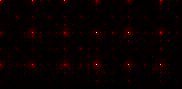

In [48]:

with Gradient(model=NN.cpu()) as attributor:
    # compute the model output and attribution
    output, attribution = attributor(X, target)

relevance = attribution.abs().sum(1)

# create an image of the visualize attribution the relevance is only
# positive, so we use symmetric=False and an unsigned color-map
img = imgify(relevance, symmetric=False, cmap='hot')

# show the image
display(img)

Prediction: 3


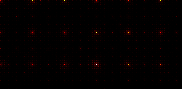

In [51]:
# create the attributor, specifying model
with SmoothGrad(noise_level=0.1, n_iter=20, model=model) as attributor:
    # compute the model output and attribution
    output, attribution = attributor(X, target)

print(f'Prediction: {output.argmax(1)[0].item()}')

relevance = attribution.abs().sum(1)

# create an image of the visualize attribution the relevance is only
# positive, so we use symmetric=False and an unsigned color-map
img = imgify(relevance, symmetric=False, cmap='hot')

# show the image
display(img)


Prediction: 3


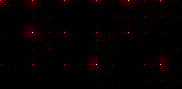

In [53]:
composite = EpsilonPlusFlat()

# choose a target class for the attribution (label 437 is lighthouse)

# create the attributor, specifying model and composite
with Gradient(model=model, composite=composite) as attributor:
    # compute the model output and attribution
    output, attribution = attributor(X, target)

print(f'Prediction: {output.argmax(1)[0].item()}')
relevance = attribution.abs().sum(1)

# create an image of the visualize attribution the relevance is only
# positive, so we use symmetric=False and an unsigned color-map
img = imgify(relevance, symmetric=False, cmap='hot')

# show the image
display(img)

In [23]:
def lrp_gradient(layer: torch.nn.Linear, a: torch.tensor, r: torch.tensor) -> torch.tensor:
    eps = 1.0e-05
    z = layer.forward(a) + eps
    s = (r / z).data
    (z * s).sum().backward()
    c = a.grad
    r = (a * c).data
    return r


In [24]:
def lrp_manually(layer: torch.nn.Linear, a: torch.tensor, r: torch.tensor) -> torch.tensor:
    eps = 1.0e-05
    z = layer.forward(a) + eps
    s = r / z
    c = torch.mm(s, layer.weight)
    r = (a * c).data
    return r


In [26]:
def relevance_filter(r: torch.tensor, top_k_percent: float = 1.0) -> torch.tensor:
    """Filter that allows largest k percent values to pass for each batch dimension.

    Filter keeps largest k% entries of a tensor. All tensor elements are set to
    zero except for the largest k % values. Here, k = 1 means that all relevance
    scores are passed on to the next layer.

    Args:
        r: Tensor holding relevance scores of current layer.
        top_k_percent: Proportion of top k values that is passed on.

    Returns:
        Tensor of same shape as input tensor.

    """
    assert 0.0 <= top_k_percent <= 1.0

    if top_k_percent < 1.0:
        size = r.size()
        r = r.flatten(start_dim=1)
        num_elements = r.size(-1)
        k = int(top_k_percent * num_elements)
        assert k > 0, f"Expected k to be larger than 0."
        top_k = torch.topk(input=r, k=k, dim=-1)
        r = torch.zeros_like(r)
        r.scatter_(dim=1, index=top_k.indices, src=top_k.values)
        return r.view(size)
    else:
        return r

class RelevancePropagationConv2d(nn.Module):
    """Layer-wise relevance propagation for 2D convolution.

    Optionally modifies layer weights according to propagation rule. Here z^+-rule

    Attributes:
        layer: 2D convolutional layer.
        eps: a value added to the denominator for numerical stability.

    """

    def __init__(self, layer: torch.nn.Conv2d, mode: str = "z_plus", eps: float = 1.0e-05) -> None:
        super().__init__()

        self.layer = layer

        if mode == "z_plus":
            self.layer.weight = torch.nn.Parameter(self.layer.weight.clamp(min=0.0))
            self.layer.bias = torch.nn.Parameter(torch.zeros_like(self.layer.bias))

        self.eps = eps

    def forward(self, a: torch.tensor, r: torch.tensor) -> torch.tensor:
        r = relevance_filter(r, top_k_percent=1.0)
        z = self.layer.forward(a) + self.eps
        s = (r / z).data
        (z * s).sum().backward()
        c = a.grad
        r = (a * c).data
        return r


In [ ]:
lrp_model = LRPModel(NN)

In [ ]:
from captum.attr._utils.lrp_rules import IdentityRule, EpsilonRule
import torch.nn as nn

def attach_default_lrp_rules(model, eps=1e-6):
    for m in model.modules():
        if isinstance(m, (nn.ReLU, nn.LeakyReLU, nn.GELU, nn.SiLU, nn.Identity)):
            m.rule = IdentityRule()        # pass relevance through
        elif isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d, nn.Linear)):
            m.rule = EpsilonRule(eps)      # stable for conv/linear
        elif isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            # should already be stripped; set Identity just in case
            m.rule = IdentityRule()
    return model

In [22]:
from captum.attr import LRP
import copy, torch, torch.nn as nn
from captum.attr import LRP
from captum.attr._utils.lrp_rules import IdentityRule, EpsilonRule

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- make a clean attribution copy (no dropout, dedup activations) ---
def prep_for_lrp(model: nn.Module) -> nn.Module:
    m = copy.deepcopy(model)
    # remove dropout
    for name, child in list(m.named_modules()):
        if isinstance(child, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            parent = dict(m.named_modules())[name.rsplit('.',1)[0]] if '.' in name else m
            setattr(parent, name.split('.')[-1], nn.Identity())
    # optional: replace LeakyReLU with ReLU to avoid reuse/rule quirks
    for name, child in list(m.named_modules()):
        if isinstance(child, nn.LeakyReLU):
            parent = dict(m.named_modules())[name.rsplit('.',1)[0]] if '.' in name else m
            setattr(parent, name.split('.')[-1], nn.ReLU(inplace=False))
    return m

def attach_default_lrp_rules(model: nn.Module, eps=1e-6):
    # IMPORTANT: call this AFTER model.to(device)
    for mod in model.modules():
        if isinstance(mod, (nn.ReLU, nn.GELU, nn.SiLU, nn.Identity)):
            mod.rule = IdentityRule()
        elif isinstance(mod, (nn.Conv1d, nn.Conv2d, nn.Conv3d, nn.Linear)):
            mod.rule = EpsilonRule(eps)
        # do NOT attach rules to modules that won't be used
    return model

# 1) prepare model on the target device FIRST
NN_lrp = prep_for_lrp(NN).to(device).eval()

# 2) attach rules on the SAME device (fresh objects, no stale caches)
attach_default_lrp_rules(NN_lrp)

# 3) build LRP object now
lrp = LRP(NN_lrp)

# If your model outputs a SINGLE logit per sample, omit target (or use target=0)
attr = lrp.attribute(X.to(device), target=0)   


KeyError: device(type='cuda', index=0)

In [7]:
from collections import defaultdict
class CallCounter:
    def __init__(self, model, types=(nn.LeakyReLU,)):
        self.model = model
        self.types = types
        self.counts = defaultdict(int)
        self.names = {}
        self.handles = []

        # map id(module) -> dotted name
        for name, m in model.named_modules():
            self.names[id(m)] = name if name else "<root>"

        for m in model.modules():
            if isinstance(m, self.types):
                self.handles.append(
                    m.register_forward_pre_hook(self._inc)
                )

    def _inc(self, m, inp):
        self.counts[id(m)] += 1

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles.clear()

def find_multi_called_modules(model, sample_input, types=(nn.LeakyReLU,)):
    tracer = CallCounter(model, types)
    model.eval()
    with torch.no_grad():
        _ = model(sample_input)  # one dry forward with a representative batch
    # collect results
    results = []
    for mid, c in tracer.counts.items():
        if c > 1:
            name = tracer.names.get(mid, "<unnamed>")
            # recover module object
            mod = None
            for m in model.modules():
                if id(m) == mid:
                    mod = m; break
            results.append((name, repr(mod), c))
    tracer.remove()
    if not results:
        print("✅ No modules from the given types were called more than once.")
    else:
        print("⚠️ Modules called multiple times:")
        for name, modrepr, c in results:
            print(f"  {name}: {modrepr}  — calls: {c}")
    return results

In [8]:
X = dataloader.train_loader.dataset[0][0][:1]

find_multi_called_modules(NN, X, types=(nn.LeakyReLU, nn.Dropout, nn.ReLU))

✅ No modules from the given types were called more than once.


[]

In [7]:
import torchvision.models as models
resnet = models.resnet18(weights=None)   # weights="IMAGENET1K_V1" for pretrained on ImageNet
resnet.conv1 = nn.Conv2d(
    in_channels=4,   # e.g. 4 atmospheric variables
    out_channels=64,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)
resnet.fc = nn.Linear(resnet.fc.in_features, 7)  # binary classification


In [8]:
X = dataloader.train_loader.dataset[0][0]

In [9]:
NN = resnet
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), 
            get_checkpoint_callback(wandb_logger),
            BestF1Callback(multi_horizon=True)
        #    LogF1Validation(num_timesteps=config['num_timesteps_predicted']),
            ]
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

trainer = AttributableTrainer(limit_train_batches=100, 
                            max_epochs=config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator=accelerator, devices=1)

loss = get_loss(config)
lightning_model = ExtremeRainPredictor(NN, 
                        learning_rate=config['learning_rate'], 
                        lr_scheduler =config['lr_scheduler'],
                        loss_fn = loss,
                        init_config=init_config)
trainer.fit(lightning_model,dataloader.train_loader, dataloader.val_loader)
lightning_model.eval()
lightning_model.model.eval()
with torch.no_grad():
    trainer.test(lightning_model, dataloaders=dataloader.val_loader)
wandb.finish()



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:658: Checkpoint directory /felles_gfi/felles_gfi_users/rogui7909/data/NN_outputs/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type                         | Params | Mode 
-----------------------------------------------------------------
0 | model   | ResNet                       | 11.2 M | train
1 | loss_fn | BCEWithLogitsHorizonWeighted | 0      | train
-----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.692    Total estimated model params size (MB)
69        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           1.6781517267227173
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


epoch,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇██
test/best_f1,▁
test/best_threshold,▁
test/loss,▁
train/loss,▆▇▆█▆▅▇▄▆▅▄▄▄▄▅▄▄▄▃▃▄▄▃▃▂▃▄▃▃▃▃▂▂▁▃▂▁▃▂▂
trainer/global_step,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇█████
val/loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
test/best_f1,0.23533
test/best_threshold,0.74
test/loss,1.67815


In [11]:
from tqdm import tqdm
all_targets = []
all_preds = []
for batch in tqdm(dataloader.val_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_preds.append(lightning_model(x))
    all_targets.append(y)
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.nn.Sigmoid()(torch.cat(all_preds)).cpu().numpy()

ds_aligned = dataloader.ds_val.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da

100%|██████████| 18/18 [00:31<00:00,  1.74s/it]


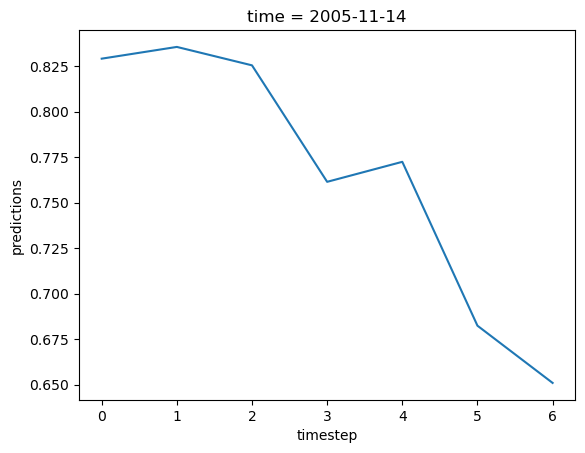

In [12]:
ds_aligned.sel(time='2005-11-14').predictions.plot()

In [13]:
X = torch.Tensor(ds_aligned.sel(time=['2005-11-14']).features.values)


In [25]:
model

ExtremeRainPredictor(
  (model): ResNet(
    (conv1): Conv2d(4, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [31]:
X

tensor([[[[-1.8672, -1.8337, -1.7991,  ...,  0.5761,  0.5827,  0.5888],
          [-1.9184, -1.8689, -1.8185,  ...,  0.2237,  0.2368,  0.2505],
          [-1.4199, -1.3849, -1.3487,  ..., -0.1052, -0.0813, -0.0582],
          ...,
          [-0.9360, -1.0088, -1.0708,  ..., -1.5689, -1.3689, -1.1734],
          [-0.9427, -0.9878, -1.0398,  ..., -1.8555, -1.6834, -1.5712],
          [-0.8847, -0.9375, -0.9956,  ..., -1.5071, -1.5006, -1.4448]],

         [[ 0.9706,  0.9933,  1.0155,  ...,  0.1049,  0.0962,  0.0868],
          [ 1.3686,  1.3879,  1.4052,  ...,  0.2894,  0.2874,  0.2855],
          [ 1.5794,  1.6014,  1.6224,  ...,  0.4600,  0.4685,  0.4758],
          ...,
          [ 0.3445,  0.4964,  0.5075,  ..., -0.1915, -0.3911, -0.7204],
          [-0.0366,  0.0880,  0.1268,  ..., -0.1618, -0.3630, -0.6055],
          [-0.5150, -0.3287, -0.2002,  ...,  0.2464,  0.3356,  0.1429]],

         [[ 0.3500,  0.3559,  0.3622,  ...,  0.8956,  0.8966,  0.8974],
          [ 0.0907,  0.1025,  

In [36]:
from captum.attr import IntegratedGradients, LRP
model = lightning_model.model
model.eval()
ig = IntegratedGradients(model)
lrp = LRP(model) 


# def attach_lrp_rules(model, act_rule="identity", eps=1e-6):
#     for m in model.modules():
#         if isinstance(m, ml_module_rain.models.losses.BCEWithLogitsHorizonWeighted):
#             m.rule = IdentityRule() if act_rule == "identity" else EpsilonRule(eps)
#         if isinstance(m, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
#             m.rule = IdentityRule()
#         # (optional) explicitly set rules for linears / convs too:
#         # elif isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Conv3d, nn.Linear)):
#         #     m.rule = EpsilonRule(eps)
#     return model

# _ = attach_lrp_rules(model, act_rule="identity")


attr_ig =ig.attribute(X, baselines=0, target=0)
attr_lrp =lrp.attribute(X, target=0)


AttributeError: 'NoneType' object has no attribute 'relevance_input'

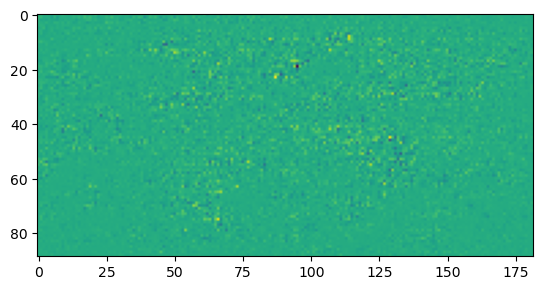

In [35]:
import matplotlib.pyplot as plt
plt.imshow(attr_ig[0,0]+attr_ig[0,1]+attr_ig[0,2])